In [1]:
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import Image, display
from plotly.subplots import make_subplots

In [2]:
def _pmf_centers(values, bins):
    counts, edges = np.histogram(values, bins=bins)
    return counts / counts.sum(), 0.5 * (edges[:-1] + edges[1:])


def scatter_dmu_dsigma(
    df,
    sample_size=None,
    output_path="scatter.png",
    fig_width=170,
    scatter_height=85,
    hist_ratio=0.2,
    hist_x_color="#C9C9C9",
    hist_y_color="#C9C9C9",
):
    df_plot = df.sample(n=sample_size, seed=0) if sample_size is not None else df

    # layout sizes
    hist_pix = fig_width * hist_ratio
    total_height = scatter_height + hist_pix
    row_heights = [hist_pix / total_height, scatter_height / total_height]
    col_widths = [1 - hist_ratio, hist_ratio]

    fig = make_subplots(
        rows=2,
        cols=2,
        specs=[[{"type": "xy"}, None], [{"type": "xy"}, {"type": "xy"}]],
        row_heights=row_heights,
        column_widths=col_widths,
        horizontal_spacing=0.015,
        vertical_spacing=0.015,
    )

    # scatter
    colorscale = [
        [0.0, "#70AD47"],
        [0.2, "#A9D18E"],
        [0.4, "#C5E0B4"],
        [0.6, "#EBB5BF"],
        [0.8, "#E18FA0"],
        [1.0, "#CD4560"],
    ]
    fig.add_trace(
        go.Scatter(
            x=df_plot["d_mu"].to_numpy(),
            y=df_plot["d_sigma"].to_numpy(),
            mode="markers",
            marker=dict(
                size=0.25,
                color=df_plot["socm"].to_numpy(),
                colorscale=colorscale,
                cmin=0.0,
                cmax=1.0,
                showscale=False,
            ),
        ),
        row=2,
        col=1,
    )

    # marginal histograms (PMF, absolute bins)
    bin_width = 0.03
    bins = np.arange(0.0, 1.0 + bin_width, bin_width)

    # (col_name, row, col, horizontal, color)
    hist_traces = [
        ("d_mu", 1, 1, False, hist_x_color),
        ("d_sigma", 2, 2, True, hist_y_color),
    ]
    for col_name, row, col, horizontal, color in hist_traces:
        pmf, centers = _pmf_centers(df_plot[col_name].to_numpy(), bins)
        x, y = (pmf, centers) if horizontal else (centers, pmf)
        fig.add_trace(
            go.Bar(
                x=x,
                y=y,
                orientation="h" if horizontal else None,
                width=bin_width,
                marker=dict(color=color, line=dict(width=0)),
            ),
            row=row,
            col=col,
        )

    # axes
    fig.update_xaxes(
        row=2,
        col=1,
        range=[0, 1],
        tickvals=[0, 0.5, 1.0],
        showgrid=True,
        gridcolor="lightgray",
    )
    fig.update_yaxes(
        row=2,
        col=1,
        range=[0, 1],
        tickvals=[0, 0.5, 1.0],
        showgrid=True,
        gridcolor="lightgray",
    )
    for r, c in [(1, 1), (2, 2)]:
        fig.update_xaxes(row=r, col=c, showticklabels=False)
        fig.update_yaxes(row=r, col=c, showticklabels=False)

    # layout and style
    fig.update_layout(
        width=fig_width,
        height=total_height,
        margin=dict(l=5, r=5, t=20, b=5),
        font=dict(family="Times New Roman", size=16, color="black"),
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        bargap=0.0,
        showlegend=False,
    )

    # panel borders
    border = dict(color="black", width=0.8)
    panels = [("xaxis", "yaxis"), ("xaxis2", "yaxis2"), ("xaxis3", "yaxis3")]
    for xa, ya in panels:
        x0, x1 = fig.layout[xa].domain
        y0, y1 = fig.layout[ya].domain
        fig.add_shape(
            type="rect",
            xref="paper",
            yref="paper",
            x0=x0,
            x1=x1,
            y0=y0,
            y1=y1,
            line=border,
        )

    # save and display
    output_path = Path(output_path)
    png_path = output_path.with_suffix(".png")
    # pdf_path = output_path.with_suffix(".pdf")

    png_path.parent.mkdir(parents=True, exist_ok=True)
    fig.write_image(
        png_path, width=fig_width, height=total_height, scale=1, format="png"
    )
    # fig.write_image(pdf_path, width=fig_width, height=total_height, scale=1, format="pdf")

    display(Image(filename=str(png_path)))

google-bert/bert-base-uncased


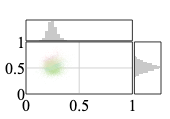

h-tomo/unsup-simcse-bert-base-uncased-mean


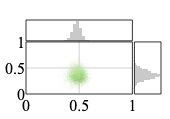

intfloat/e5-base-v2


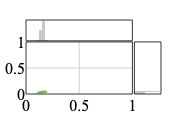

thenlper/gte-base


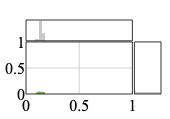

microsoft/MiniLM-L12-H384-uncased


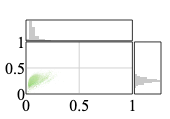

sentence-transformers/all-MiniLM-L12-v2


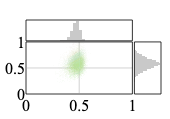

intfloat/e5-small-v2


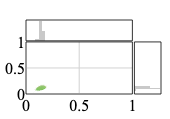

thenlper/gte-small


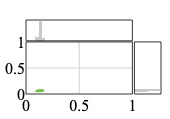

microsoft/mpnet-base


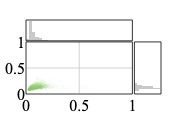

sentence-transformers/all-mpnet-base-v2


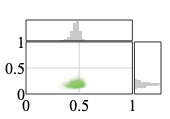

nomic-ai/nomic-bert-2048


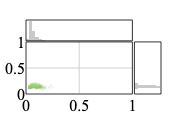

nomic-ai/nomic-embed-text-v1.5


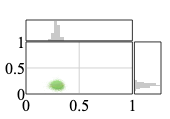

In [3]:
dataset_name = "wiki_1000"
model_names = [
    "google-bert/bert-base-uncased",
    "h-tomo/unsup-simcse-bert-base-uncased-mean",
    "intfloat/e5-base-v2",
    "thenlper/gte-base",
    "microsoft/MiniLM-L12-H384-uncased",
    "sentence-transformers/all-MiniLM-L12-v2",
    "intfloat/e5-small-v2",
    "thenlper/gte-small",
    "microsoft/mpnet-base",
    "sentence-transformers/all-mpnet-base-v2",
    "nomic-ai/nomic-bert-2048",
    "nomic-ai/nomic-embed-text-v1.5",
]

for model_name in model_names:
    print(model_name)
    df = pl.read_csv(
        f"../results/socm/{dataset_name}_{model_name.replace('/', '-')}.csv"
    )
    scatter_dmu_dsigma(
        df,
        sample_size=20000,
        output_path=f"./figs/scatter_dmu_dsigma/{model_name.replace('/', '-')}.png",
    )